# Network Science - UDD

## Básicos en redes


#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 


# Importando Modulos Requeridos


In [91]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

import networkx as nx

In [92]:
# default settings para plotear Redes
mpl.rc('xtick', labelsize=14, color="#222222") 
mpl.rc('ytick', labelsize=14, color="#222222") 
mpl.rc('font', **{'family':'sans-serif','sans-serif':['Arial']})
mpl.rc('font', size=16)
mpl.rc('xtick.major', size=6, width=1)
mpl.rc('xtick.minor', size=3, width=1)
mpl.rc('ytick.major', size=6, width=1)
mpl.rc('ytick.minor', size=3, width=1)
mpl.rc('axes', linewidth=1, edgecolor="#222222", labelcolor="#222222")
mpl.rc('text', usetex=False, color="#222222")

# Tipos básicos de data en NetworkX
NetworkX proporciona las siguientes clases que representan datos relacionados con la red,
así como algoritmos de análisis de red que operan en estos objetos:

**Graph**       - Grafos no dirigidos con auto-loops

**DiGraph**      - Grafos dirigidos con auto-loops

**MultiGraph**   - Grafo no-dirigidos con auto-loops y enlaces múltiples

**MultiDiGraph** - Grafos dirigidos con auto-loops y enlaces múltiples

# Comencemos 
Crea una red vacía y no-dirigida

In [93]:
G = nx.Graph()

In [94]:
G

# Nodos
Los nodos pueden ser casi cualquier cosa, incluyendo nombres, strings, coordenadas GPS, tú los nombras!

Es posible agregar nodos uno a la vez:

In [95]:
G.add_node(0)

G.add_node("Juan")

# objeto tupla representando, por ejemplo, longitud y latitud
G.add_node((1.2, 3.4))

In [96]:
G.nodes()

NodeView((0, 'Juan', (1.2, 3.4)))

... o muchos a la vez desde un contenedor de python

In [97]:
# [1,2,3] es una lista que contiene 1, 2 y 3
G.add_nodes_from([1, 2, 3,"Carlos"])

In [98]:
G.nodes()

NodeView((0, 'Juan', (1.2, 3.4), 1, 2, 3, 'Carlos'))

# Atributos de los Nodos
Los nodos pueden tener atributos arbitrarios asociados a ellos, contenidos en un diccionario string-index

Agragar atributos en el momento en que creamos un nodo usando argumentos:

In [99]:
G.add_node("Jorge", color_ojos='amarillos', estatura=175)

In [102]:
G.nodes(data=True)

NodeDataView({0: {}, 'Juan': {}, (1.2, 3.4): {}, 1: {}, 2: {}, 3: {}, 'Carlos': {}, 'Jorge': {'color_ojos': 'amarillos', 'estatura': 175}})

Tambien puedes agregar atributos a un nodo existente:

In [105]:
G.add_node("Camila")
G.nodes['Camila']

{}

In [106]:
G.nodes["Camila"]["color_ojos"] = "rojo"
G.nodes["Camila"]["edad"] = "23"

In [107]:
G.nodes["Camila"]

{'color_ojos': 'rojo', 'edad': '23'}

In [108]:
G.nodes(data=True)

NodeDataView({0: {}, 'Juan': {}, (1.2, 3.4): {}, 1: {}, 2: {}, 3: {}, 'Carlos': {}, 'Jorge': {'color_ojos': 'amarillos', 'estatura': 175}, 'Camila': {'color_ojos': 'rojo', 'edad': '23'}})

G.node[n] da un diccionario que contiene todos los atributos: pares de valores asociados con el nodo n

In [109]:
print("Los ojos de Jorge son ", G.nodes["Jorge"]["color_ojos"], " y el mide ", G.nodes['Jorge']['estatura'], " centímetros.")
print("Camila tiene el cabello de color ", G.nodes["Camila"]["color_ojos"], ".")

Los ojos de Jorge son  amarillos  y el mide  175  centímetros.
Camila tiene el cabello de color  rojo .


# Enlaces

Un enlace entre el nodo 1 y el nodo 2 es representado por una tupla (nodo 1, nodo 2).

Ellos pueden ser agregados uno a la vez:

In [110]:
# agrega un enlace entre el nodo 0 y el nodo 1
G.add_edge(0, 1)
G.add_edge('Camila', 100)

In [111]:
G.edges()

EdgeView([(0, 1), ('Camila', 100)])

In [112]:
G.nodes()

NodeView((0, 'Juan', (1.2, 3.4), 1, 2, 3, 'Carlos', 'Jorge', 'Camila', 100))

O mucho a la vez desde un contenedor:

In [113]:
edge_list = [ (2, 1), ("Jorge", "Camila"), (3, 4), ("A","B") ]

G.add_edges_from(edge_list)

In [114]:
print(G.edges())
# print(G.nodes())

[(0, 1), (1, 2), (3, 4), ('Jorge', 'Camila'), ('Camila', 100), ('A', 'B')]


**Nota:** Los nodos serán creados automáticamente si ellos no existen aún.

# Atributos de los Enlaces

Como para los nodos, los enlaces pueden tener atributos arbitrarios. Un atributo importante y especial (para muchos algoritmos) es el "peso"

La sintaxis para agregar/accesar a los atributos de los enlaces es similar a la de los nodos:

In [115]:
G.add_edge("Jorge", "Claudia", weight=10) # weight en general es un string reservado para algunos algortimos de cerntralidad y comunidades en red.
G.add_edge("Jorge", "Claudia", distancia=20)

G.add_edge("Concepcion", "Santiago")

G.add_edge("Concepcion","Santiago", distancia=510)

In [118]:
print(G.edges(data=True))
print('----')
print(G.edges["Concepcion","Santiago"])

[(0, 1, {}), (1, 2, {}), (3, 4, {}), ('Jorge', 'Camila', {}), ('Jorge', 'Claudia', {'weight': 10, 'distancia': 20}), ('Camila', 100, {}), ('A', 'B', {}), ('Concepcion', 'Santiago', {'distancia': 510})]
----
{'distancia': 510}


`G.edges['node1','node2']` es un diccionario que contiene todos los atributos: pares de valores asociados con el enlace del nodo 1 al nodo 2.

# Operaciones Básicas

### Tamaño de la red

In [119]:
# Número de nodos
print(G.number_of_nodes())

# alternativa
print(len(G))

####################

# Número de enlaces
print(G.number_of_edges())

# Mejor
print(G.size())

########################
# cómo hacer formateo de strings
print("El grafo G tiene {0} nodos y {1} enlaces.".format(len(G), G.size()))

16
16
8
8
El grafo G tiene 16 nodos y 8 enlaces.


### Testeando si nodos y enlaces existen

In [122]:
G.has_node("Jorge")

True

Alternativa pythonica

In [125]:
"Claudia" in G

True

Para los enlaces, tu debes usar has_edges (no hay una sintaxisis como para nos lodos `edge in G`) =(

In [126]:
print(G.has_edge(3, 4))
print(G.has_edge("Jorge", 0))

True
False


### Encontrando los vecinos de un nodo

In [127]:
print(list(G.neighbors("Camila")))
print(list(G.neighbors(1)))

[100, 'Jorge']
[0, 2]


* En un objeto `DiGraph`, `G.neighbors(node)` entrega el nodo sucesor de `node`, como lo hace `G.successors(node)` (enlace out) 
* Predecesores de `node` pueden ser obtenidos con `G.predecessors(node)` (enlace in)

### Iterando sobre los nodos y enlaces
Nodos y enlaces pueden ser iterados con `G.nodes()` y `G.edges()` respectivamente.  

In [128]:
list(G.nodes(data=True))

[(0, {}),
 ('Juan', {}),
 ((1.2, 3.4), {}),
 (1, {}),
 (2, {}),
 (3, {}),
 ('Carlos', {}),
 ('Jorge', {'color_ojos': 'amarillos', 'estatura': 175}),
 ('Camila', {'color_ojos': 'rojo', 'edad': '23'}),
 (100, {}),
 (4, {}),
 ('A', {}),
 ('B', {}),
 ('Claudia', {}),
 ('Concepcion', {}),
 ('Santiago', {})]

In [132]:
for nodo, atributos in list(G.nodes(data=True)): # data=True incluye atributos de nodo como diccionarios
    print("Nodo {0}, atributo: {1}".format(nodo, atributos))

Nodo 0, atributo: {}
Nodo Juan, atributo: {}
Nodo (1.2, 3.4), atributo: {}
Nodo 1, atributo: {}
Nodo 2, atributo: {}
Nodo 3, atributo: {}
Nodo Carlos, atributo: {}
Nodo Jorge, atributo: {'color_ojos': 'amarillos', 'estatura': 175}
Nodo Camila, atributo: {'color_ojos': 'rojo', 'edad': '23'}
Nodo 100, atributo: {}
Nodo 4, atributo: {}
Nodo A, atributo: {}
Nodo B, atributo: {}
Nodo Claudia, atributo: {}
Nodo Concepcion, atributo: {}
Nodo Santiago, atributo: {}


In [133]:
list(G.edges(data=True))

[(0, 1, {}),
 (1, 2, {}),
 (3, 4, {}),
 ('Jorge', 'Camila', {}),
 ('Jorge', 'Claudia', {'weight': 10, 'distancia': 20}),
 ('Camila', 100, {}),
 ('A', 'B', {}),
 ('Concepcion', 'Santiago', {'distancia': 510})]

In [137]:
for n1, n2, atributo in list(G.edges(data=True)):
    print("El primer nodo {0} <----> con el nodo {1}: su atributo es {2}".format(n1, n2, atributo))

El primer nodo 0 <----> con el nodo 1: su atributo es {}
El primer nodo 1 <----> con el nodo 2: su atributo es {}
El primer nodo 3 <----> con el nodo 4: su atributo es {}
El primer nodo Jorge <----> con el nodo Camila: su atributo es {}
El primer nodo Jorge <----> con el nodo Claudia: su atributo es {'weight': 10, 'distancia': 20}
El primer nodo Camila <----> con el nodo 100: su atributo es {}
El primer nodo A <----> con el nodo B: su atributo es {}
El primer nodo Concepcion <----> con el nodo Santiago: su atributo es {'distancia': 510}


### Calculando grados

In [138]:
# one node
print(G.degree("Jorge")) # retorna un entero

# todos los nodos (retorna un diccionario con pares nodo : grado para todos los nodos)
print(G.degree())

# solo la secuencia de grados
print(list(dict(G.degree()).values()))

2
[(0, 1), ('Juan', 0), ((1.2, 3.4), 0), (1, 2), (2, 1), (3, 1), ('Carlos', 0), ('Jorge', 2), ('Camila', 2), (100, 1), (4, 1), ('A', 1), ('B', 1), ('Claudia', 1), ('Concepcion', 1), ('Santiago', 1)]
[1, 0, 0, 2, 1, 1, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1]


In [140]:
G.edges("Jorge")

EdgeDataView([('Jorge', 'Camila'), ('Jorge', 'Claudia')])

Como sabes, en un grafo dirigido (de clase `DiGraph`) hay dos tipos de grados. Las cosas funcionan tal cual como tu lo esperas:
* `G.in_degree(node) `
* `G.out_degree(node) # igual que G.degree()`


# Otras operaciones

* ***`subgraph(G, nbunch)` or `G.subgraph(nbunch)`***       
subgrafo de G inducido por los nodos en nbunch    

* ***`reverse(G)`***       
DiGraph con enlaces al revés

* ***`union(G1, G2)`***      
unión de grafos

* ***`disjoint_union(G1, G2)`***     
Igual, pero con trata a los nodos de G1 y G2 como distintos

* ***`intersection(G1, G2)`***      
grafo con solo los enlaces en común entre G1 y G2

* ***`difference(G1, G2)`***      
grafo con solo los enlaces G1 que no estan en G2

* ***`copy(G)` or `G.copy()`***     
copia de G

* ***`complement(G)` or `G.complement()`***     
El complemento del grafo G

* ***`convert_to_undirected(G)` or `G.to_undirected()`***     
versión no-dirigida de G (un grafo o multigrafo)

* ***`convert_to_directed(G)` or `G.to_directed()`***      
versión dirigida de G (un digrafo o multigrafo)

* ***`adjacency_matrix(G)`***      
Matriz de adjacencia A del grafo G (en formato de matriz sparse; para obtener la matriz completa (con las entradas iguales a cero, usa A.toarray() )

# Graph I/O

Habitualmente, tú no construiras una red desde cero, un nodo link a la vez. Por el contrario, tú querras leer un la red desde un archivo. NetworkX puede entender los siguientes formatos de grafos:

* edge lists
* adjacency lists
* GML
* GEXF
* Python 'pickle'
* GraphML
* Pajek
* LEDA
* YAML

# Datos Reales
Vamos a: 

1. Cargar un dataset real desde un repositorio público.
2. Inspeccionar su estructura como tabla relacional.
3. Construir una edgelist limpia.
4. Convertirla en un grafo con `networkx`.
5. Inspecionar una matriz de adyacencia.
6. Calcular grado y chequeos básicos de control de calidad.

Dataset usado:
- Repositorio público: `mathbeveridge/asoiaf`
- Archivo: `asoiaf-book3-edges.csv`

**Idea sustantiva del dataset**  
Cada fila representa una interacción entre dos personajes de un libro, con un peso asociado.

In [141]:
# ============================================================
# 0. Importar librerías
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx

# Opcional: para visualizaciones rápidas
import matplotlib.pyplot as plt

## 1) Cargar los datos

Vamos a leer directamente un CSV público desde GitHub.
Trabajaremos con una red no dirigida y ponderada de interacciones entre personajes.

In [144]:
# ============================================================
# 1. Cargar datos desde un repositorio público
# ============================================================

url = "https://raw.githubusercontent.com/mathbeveridge/asoiaf/master/data/asoiaf-book3-edges.csv"

# Leemos el archivo CSV directamente desde la URL
df_raw = pd.read_csv(url)

# Mostramos las primeras filas para inspección inicial
df_raw.head(20)

,Source,Target,Type,weight,book
0,Addam-Marbrand,Gyles-Rosby,Undirected,3,3
1,Addam-Marbrand,Jaime-Lannister,Undirected,3,3
2,Addam-Marbrand,Jalabhar-Xho,Undirected,3,3
3,Addam-Marbrand,Joffrey-Baratheon,Undirected,3,3
4,Addam-Marbrand,Kevan-Lannister,Undirected,3,3
5,Addam-Marbrand,Oberyn-Martell,Undirected,3,3
6,Addam-Marbrand,Tyrion-Lannister,Undirected,7,3
7,Addam-Marbrand,Varys,Undirected,4,3
8,Aegon-Frey-(son-of-Stevron),Catelyn-Stark,Undirected,4,3
9,Aegon-Frey-(son-of-Stevron),Robb-Stark,Undirected,5,3


## 2) Inspección inicial

Antes de construir la red, debemos entender qué representa cada columna.

Nos interesa especialmente:
- `Source`: nodo origen
- `Target`: nodo destino
- `weight`: intensidad o frecuencia de la relación

En este dataset, la red ya viene como lista de aristas.

In [143]:
# ============================================================
# 2. Inspección inicial del dataset
# ============================================================

# Dimensiones del dataset
print("Dimensiones del dataset:", df_raw.shape)

# Nombres de columnas
print("\nColumnas disponibles:")
print(df_raw.columns.tolist())

# Tipos de datos
print("\nTipos de datos:")
print(df_raw.dtypes)

# Conteo de valores faltantes por columna
print("\nValores faltantes por columna:")
print(df_raw.isna().sum())

Dimensiones del dataset: (1008, 5)

Columnas disponibles:
['Source', 'Target', 'Type', 'weight', 'book']

Tipos de datos:
Source    object
Target    object
Type      object
weight     int64
book       int64
dtype: object

Valores faltantes por columna:
Source    0
Target    0
Type      0
weight    0
book      0
dtype: int64


## 3) Construcción de la edgelist

Aunque el archivo ya tiene formato de aristas, igual conviene construir una versión
limpia y explícita de la edgelist que usaremos en el curso.

En esta etapa podemos:
- renombrar columnas,
- eliminar filas problemáticas,
- asegurar tipos correctos,
- dejar una estructura reproducible.

In [145]:
# ============================================================
# 3. Construir una edgelist limpia
# ============================================================

# Seleccionamos solo las columnas necesarias para el análisis inicial
df_edges = df_raw[["Source", "Target", "weight"]].copy()

# Renombramos columnas para estandarizar nombres
df_edges = df_edges.rename(columns={
    "Source": "source",
    "Target": "target",
    "weight": "weight"
})

# Aseguramos que source y target sean strings
df_edges["source"] = df_edges["source"].astype(str)
df_edges["target"] = df_edges["target"].astype(str)

# Aseguramos que weight sea numérico
df_edges["weight"] = pd.to_numeric(df_edges["weight"], errors="coerce")

# Eliminamos filas con source/target/peso faltante
df_edges = df_edges.dropna(subset=["source", "target", "weight"]).copy()

# Reiniciamos índice para dejar el dataframe ordenado
df_edges = df_edges.reset_index(drop=True)

print("Edgelist limpia construida.")
print("Filas:", len(df_edges))
df_edges.head()

Edgelist limpia construida.
Filas: 1008


,source,target,weight
0,Addam-Marbrand,Gyles-Rosby,3
1,Addam-Marbrand,Jaime-Lannister,3
2,Addam-Marbrand,Jalabhar-Xho,3
3,Addam-Marbrand,Joffrey-Baratheon,3
4,Addam-Marbrand,Kevan-Lannister,3


## 4) Primer control de calidad sobre la edgelist

Antes de crear el grafo, hacemos chequeos mínimos sobre la tabla de aristas:
- filas duplicadas,
- self-loops,
- pesos no válidos.

In [146]:
# ============================================================
# 4. QA básico sobre la edgelist
# ============================================================

# 4.1 Filas duplicadas exactas
num_duplicados_exactos = df_edges.duplicated().sum()

# 4.2 Self-loops: source == target
num_self_loops_tabla = (df_edges["source"] == df_edges["target"]).sum()

# 4.3 Pesos negativos o cero (si quisiéramos revisarlo)
num_pesos_no_positivos = (df_edges["weight"] <= 0).sum()

print("Chequeos sobre la edgelist")
print("--------------------------")
print("Duplicados exactos:", num_duplicados_exactos)
print("Self-loops en la tabla:", num_self_loops_tabla)
print("Pesos <= 0:", num_pesos_no_positivos)

Chequeos sobre la edgelist
--------------------------
Duplicados exactos: 0
Self-loops en la tabla: 0
Pesos <= 0: 0


## 5) Construir el grafo

Como este dataset representa interacciones entre pares de personajes,
usaremos un grafo **no dirigido** y **ponderado**.

Si el problema sustantivo requiriera dirección, usaríamos `nx.DiGraph()`.

In [147]:
# ============================================================
# 5. Convertir la edgelist en un grafo NetworkX
# ============================================================

G = nx.from_pandas_edgelist(
    df_edges,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.Graph()  # red no dirigida
)

print("Grafo creado correctamente.")
print(nx.info(G) if hasattr(nx, "info") else "Usando NetworkX reciente: info() puede no estar disponible.")
print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())

Grafo creado correctamente.
Usando NetworkX reciente: info() puede no estar disponible.
Número de nodos: 303
Número de aristas: 1008


## 6) Inspección rápida del grafo

Veamos algunos nodos y aristas para confirmar que la estructura quedó razonable.

In [148]:
# ============================================================
# 6. Inspección rápida del grafo
# ============================================================

# Primeros 10 nodos
print("Primeros nodos:")
print(list(G.nodes())[:10])

# Primeras 10 aristas con atributos
print("\nPrimeras aristas con peso:")
print(list(G.edges(data=True))[:10])

Primeros nodos:
['Addam-Marbrand', 'Gyles-Rosby', 'Jaime-Lannister', 'Jalabhar-Xho', 'Joffrey-Baratheon', 'Kevan-Lannister', 'Oberyn-Martell', 'Tyrion-Lannister', 'Varys', 'Aegon-Frey-(son-of-Stevron)']

Primeras aristas con peso:
[('Addam-Marbrand', 'Gyles-Rosby', {'weight': 3}), ('Addam-Marbrand', 'Jaime-Lannister', {'weight': 3}), ('Addam-Marbrand', 'Jalabhar-Xho', {'weight': 3}), ('Addam-Marbrand', 'Joffrey-Baratheon', {'weight': 3}), ('Addam-Marbrand', 'Kevan-Lannister', {'weight': 3}), ('Addam-Marbrand', 'Oberyn-Martell', {'weight': 3}), ('Addam-Marbrand', 'Tyrion-Lannister', {'weight': 7}), ('Addam-Marbrand', 'Varys', {'weight': 4}), ('Gyles-Rosby', 'Jalabhar-Xho', {'weight': 4}), ('Jaime-Lannister', 'Aemon-Targaryen-(Dragonknight)', {'weight': 3})]


## 7) Matriz de adyacencia

La misma red puede representarse como:
- edgelist
- objeto grafo
- matriz de adyacencia

Aquí construiremos una matriz de adyacencia ponderada.

In [155]:
# ============================================================
# 7. Construir matriz de adyacencia
# ============================================================

# Para que la matriz sea reproducible, fijamos un orden de nodos
node_order = sorted(G.nodes())

# Matriz de adyacencia ponderada
A = nx.to_pandas_adjacency(G, nodelist=node_order, weight="weight")

print("Dimensión de la matriz de adyacencia:", A.shape)
A.iloc[:10, :10]

Dimensión de la matriz de adyacencia: (303, 303)


,Addam-Marbrand,Aegon-Frey-(son-of-Stevron),Aegon-I-Targaryen,Aegon-Targaryen-(son-of-Rhaegar),Aemon-Targaryen-(Dragonknight),Aemon-Targaryen-(Maester-Aemon),Aerys-II-Targaryen,Aggo,Alayaya,Alerie-Hightower
Addam-Marbrand,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aegon-Frey-(son-of-Stevron),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aegon-I-Targaryen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aegon-Targaryen-(son-of-Rhaegar),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aemon-Targaryen-(Dragonknight),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aemon-Targaryen-(Maester-Aemon),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aerys-II-Targaryen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aggo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alayaya,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alerie-Hightower,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 8) Primera métrica estructural: grado

En una red no dirigida:
- el **grado** de un nodo es el número de conexiones que tiene.

Como además tenemos pesos, también podemos calcular la **fuerza**:
- suma de pesos incidentes al nodo.

In [156]:
# ============================================================
# 8. Calcular grado y fuerza
# ============================================================

# Grado simple: número de vecinos
degree_dict = dict(G.degree())

# Fuerza: suma de pesos de las aristas incidentes
strength_dict = dict(G.degree(weight="weight"))

# Convertimos a DataFrame para ordenar e inspeccionar
df_degree = pd.DataFrame({
    "node": list(degree_dict.keys()),
    "degree": list(degree_dict.values()),
    "strength": [strength_dict[n] for n in degree_dict.keys()]
})

# Ordenamos por grado descendente
df_degree = df_degree.sort_values(by=["degree", "strength"], ascending=False).reset_index(drop=True)

df_degree.head(10)

,node,degree,strength
0,Tyrion-Lannister,59,782
1,Jon-Snow,52,756
2,Joffrey-Baratheon,50,598
3,Robb-Stark,49,486
4,Sansa-Stark,48,532
5,Jaime-Lannister,45,563
6,Cersei-Lannister,38,363
7,Catelyn-Stark,38,325
8,Arya-Stark,37,442
9,Stannis-Baratheon,31,299


## 9) Control de calidad básico de la red

Ahora hacemos chequeos estructurales mínimos sobre el grafo:
- nodos
- aristas
- self-loops
- componentes conectados
- nodos aislados
- distribución básica de grado

In [157]:
# ============================================================
# 9. QA básico sobre el grafo
# ============================================================

# 9.1 Número de nodos y aristas
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

# 9.2 Self-loops en el grafo
n_self_loops = nx.number_of_selfloops(G)

# 9.3 Nodos aislados (grado 0)
isolates = list(nx.isolates(G))
n_isolates = len(isolates)

# 9.4 Componentes conectados
components = list(nx.connected_components(G))
n_components = len(components)
component_sizes = sorted([len(c) for c in components], reverse=True)

# 9.5 Resumen
print("Resumen QA del grafo")
print("--------------------")
print("Nodos:", n_nodes)
print("Aristas:", n_edges)
print("Self-loops:", n_self_loops)
print("Nodos aislados:", n_isolates)
print("Número de componentes:", n_components)
print("Tamaño de los 5 componentes más grandes:", component_sizes[:5])

Resumen QA del grafo
--------------------
Nodos: 303
Aristas: 1008
Self-loops: 0
Nodos aislados: 0
Número de componentes: 1
Tamaño de los 5 componentes más grandes: [303]


## 10) Distribución básica de grado

No haremos todavía inferencias avanzadas. Solo una inspección descriptiva.

count    303.000000
mean       6.653465
std        8.730440
min        1.000000
25%        2.000000
50%        4.000000
75%        8.000000
max       59.000000
Name: degree, dtype: float64


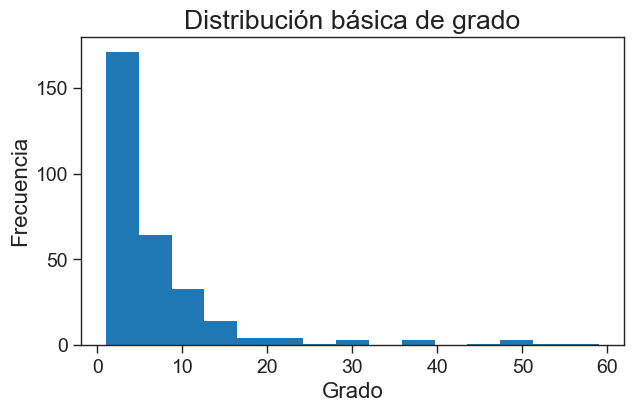

In [158]:
# ============================================================
# 10. Inspección básica de la distribución de grado
# ============================================================

# Estadísticos descriptivos del grado
print(df_degree["degree"].describe())

# Histograma simple
plt.figure(figsize=(7, 4))
plt.hist(df_degree["degree"], bins=15)
plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.title("Distribución básica de grado")
plt.show()

Primeros valores de la distribución empírica:
k =  1, P(k) = 0.1782
k =  2, P(k) = 0.1881
k =  3, P(k) = 0.1188
k =  4, P(k) = 0.0792
k =  5, P(k) = 0.0627
k =  6, P(k) = 0.0462
k =  7, P(k) = 0.0462
k =  8, P(k) = 0.0561
k =  9, P(k) = 0.0363
k = 10, P(k) = 0.0264


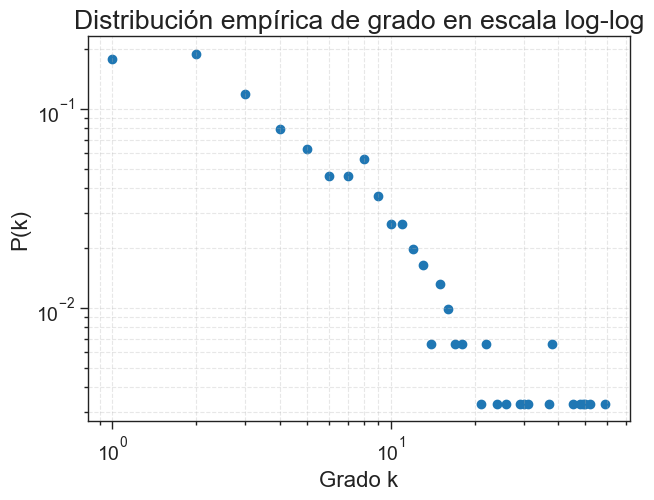

In [159]:
# ============================================================
# 10.1 Distribución de grado en escala log-log
#    (estilo clásico de network science)
# ============================================================

from collections import Counter

# Extraemos los grados como lista
degrees = [d for _, d in G.degree()]

# Contamos cuántos nodos tienen cada grado k
degree_counts = Counter(degrees)

# Ordenamos por valor de grado
k_values = np.array(sorted(degree_counts.keys()))
count_values = np.array([degree_counts[k] for k in k_values])

# Convertimos conteos a probabilidad empírica P(k)
p_k = count_values / count_values.sum()

# Mostramos algunos resultados
print("Primeros valores de la distribución empírica:")
for k, pk in zip(k_values[:10], p_k[:10]):
    print(f"k = {k:2d}, P(k) = {pk:.4f}")

# Graficamos en escala log-log
plt.figure(figsize=(7, 5))
plt.scatter(k_values, p_k)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Grado k")
plt.ylabel("P(k)")
plt.title("Distribución empírica de grado en escala log-log")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.show()

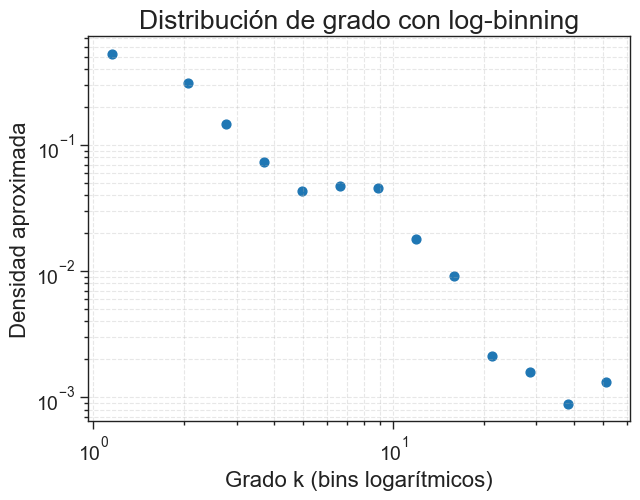

In [160]:
# ============================================================
# 10.2 PMF aproximada con log-binning
#     Útil para suavizar la cola en datos discretos
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

degrees = np.array([d for _, d in G.degree()])
degrees = degrees[degrees > 0]

# Definimos bins logarítmicos
num_bins = 15
bins = np.logspace(np.log10(degrees.min()), np.log10(degrees.max()), num_bins) #Calcula los bordes de los bins logarítmicos entre el grado mínimo y máximo

# Histograma con densidad
hist, bin_edges = np.histogram(degrees, bins=bins, density=True)

# Centros geométricos de los bins
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])# Calcula el centro geométrico de cada bin para graficar en escala logarítmica

# Eliminamos bins vacíos para no meter ceros en escala log
mask = hist > 0

plt.figure(figsize=(7, 5))
plt.scatter(bin_centers[mask], hist[mask], s=40)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Grado k (bins logarítmicos)")
plt.ylabel("Densidad aproximada")
plt.title("Distribución de grado con log-binning")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.show()

In [161]:
bins

array([ 1.        ,  1.33810265,  1.79051869,  2.3958978 ,  3.20595718,
        4.28989979,  5.74032625,  7.68114575, 10.27816145, 13.75323503,
       18.40324018, 24.62542437, 32.9513455 , 44.0922826 , 59.        ])

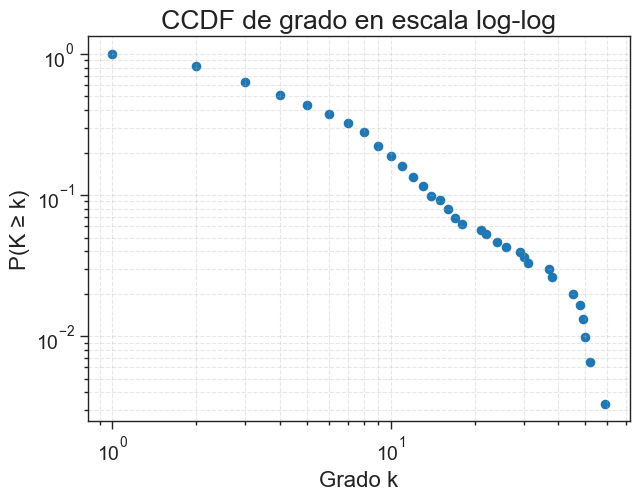

In [ ]:
# ============================================================
# 10.3. CCDF de grado en escala log-log
#     Recomendado para visualizar mejor la cola
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Extraemos los grados
degrees = np.array([d for _, d in G.degree()])

# Nos quedamos con grados positivos
degrees = degrees[degrees > 0] #check para quedarnos solo con grados positivos, ya que el CCDF se define para k >= 1 en este contexto. Si hubiera nodos aislados (grado 0), no los incluiríamos en esta gráfica porque P(K >= 0) siempre sería 1 y no aportaría información sobre la distribución de grados positivos.

# Valores únicos de grado ordenados
k_values = np.sort(np.unique(degrees))

# CCDF: P(K >= k)
ccdf = np.array([(degrees >= k).mean() for k in k_values]) # devuelve la fracción de nodos con grado >= k para cada k

# Graficamos
plt.figure(figsize=(7, 5))
plt.scatter(k_values, ccdf, s=35)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Grado k")
plt.ylabel("P(K ≥ k)")
plt.title("CCDF de grado en escala log-log")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.show()

## Distribución de grado en escala log-log

En redes complejas, una visualización clásica es la distribución empírica de grado \(P(k)\) en escala log-log.  
Esto permite inspeccionar si la red presenta una cola pesada, es decir, si existen pocos nodos con grado muy alto y muchos nodos con grado bajo.

**Importante:** una forma aproximadamente lineal en escala log-log puede ser sugestiva, pero no basta por sí sola para concluir que la red sigue una ley de potencia.

## 11) Visualización rápida del grafo

Esta visualización es solo exploratoria.
No reemplaza el análisis ni el control de calidad.

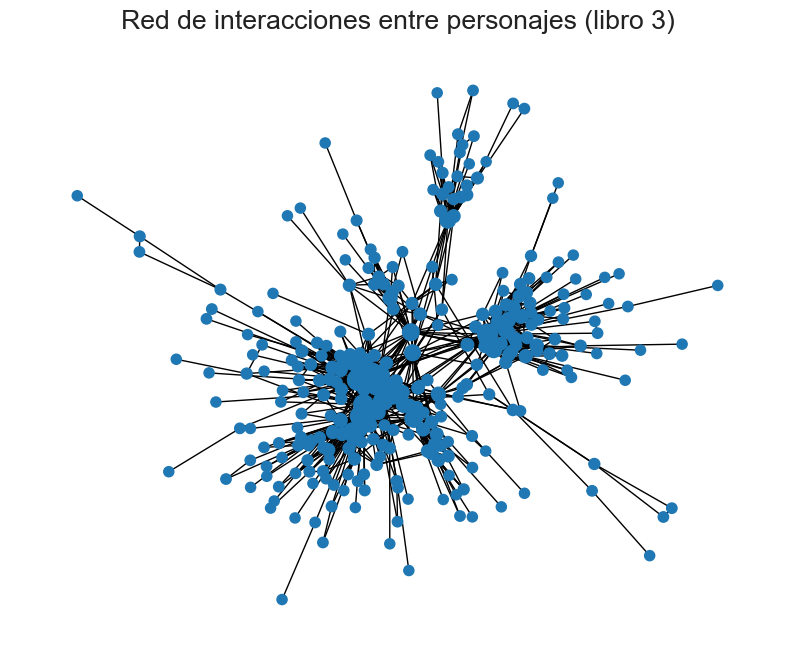

In [172]:
# ============================================================
# 11. Visualización rápida
# ============================================================

plt.figure(figsize=(10, 8))

# Spring layout para una visualización simple
pos = nx.spring_layout(G, seed=42)

# Tamaño de nodo proporcional al grado
node_sizes = [50 + 3 * degree_dict[n] for n in G.nodes()]

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=False,
    node_size=node_sizes
)

plt.title("Red de interacciones entre personajes (libro 3)")
plt.axis("off")
plt.show()

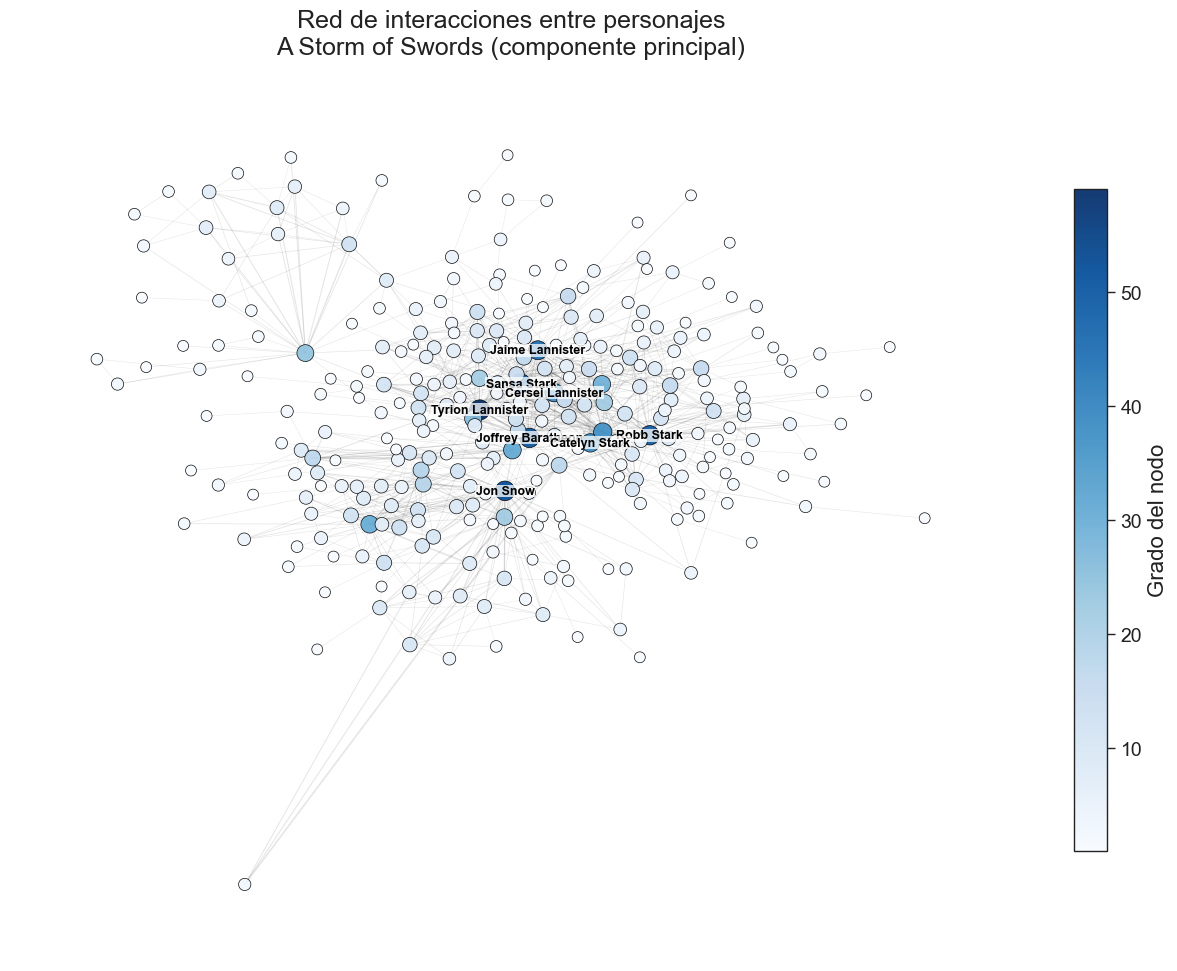

In [173]:
# ============================================================
# 11. Visualización mejorada de la red
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ------------------------------------------------------------
# 1. Quedarnos con el componente conectado más grande
# ------------------------------------------------------------
largest_cc = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()

# ------------------------------------------------------------
# 2. Calcular layout
#    Kamada-Kawai suele verse más ordenado que spring_layout
# ------------------------------------------------------------
pos = nx.kamada_kawai_layout(G_main)

# ------------------------------------------------------------
# 3. Métricas básicas para visualización
# ------------------------------------------------------------
degree_dict_main = dict(G_main.degree())
degrees_main = np.array([degree_dict_main[n] for n in G_main.nodes()])

# Tamaño de nodo: escalado suave
node_sizes = [40 + 22 * np.sqrt(degree_dict_main[n]) for n in G_main.nodes()]

# Color de nodo según grado
node_colors = degrees_main

# Ancho de arista según peso, con escalado suave
edge_weights = [d.get("weight", 1) for _, _, d in G_main.edges(data=True)]
edge_widths = [0.15 + 0.12 * np.sqrt(w) for w in edge_weights]

# ------------------------------------------------------------
# 4. Elegir pocos nodos para etiquetar
# ------------------------------------------------------------
top_n = 8
top_nodes = sorted(degree_dict_main, key=degree_dict_main.get, reverse=True)[:top_n]
labels = {n: n.replace("-", " ") for n in top_nodes}  # opcional: más legible

# ------------------------------------------------------------
# 5. Dibujar
# ------------------------------------------------------------
plt.figure(figsize=(13, 10))

# Aristas al fondo
nx.draw_networkx_edges(
    G_main,
    pos,
    width=edge_widths,
    alpha=0.10
)

# Nodos
nodes = nx.draw_networkx_nodes(
    G_main,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.Blues,
    alpha=0.95,
    linewidths=0.5,
    edgecolors="black"
)

# Etiquetas solo para hubs
text_items = nx.draw_networkx_labels(
    G_main,
    pos,
    labels=labels,
    font_size=9,
    font_weight="bold"
)

# Agregar fondo blanco a las etiquetas para que no se pierdan
for _, text in text_items.items():
    text.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.2))

# Barra de color
cbar = plt.colorbar(nodes, shrink=0.75)
cbar.set_label("Grado del nodo", rotation=90)

plt.title(
    "Red de interacciones entre personajes\nA Storm of Swords (componente principal)",
    fontsize=18,
    pad=18
)

plt.axis("off")
plt.tight_layout()
plt.show()

Número de comunidades detectadas: 6
Tamaños: [81, 75, 73, 39, 31, 4]


/var/folders/q8/5g879lls62l1z8smyjkh4h700000gn/T/ipykernel_67015/4008283418.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(communities))


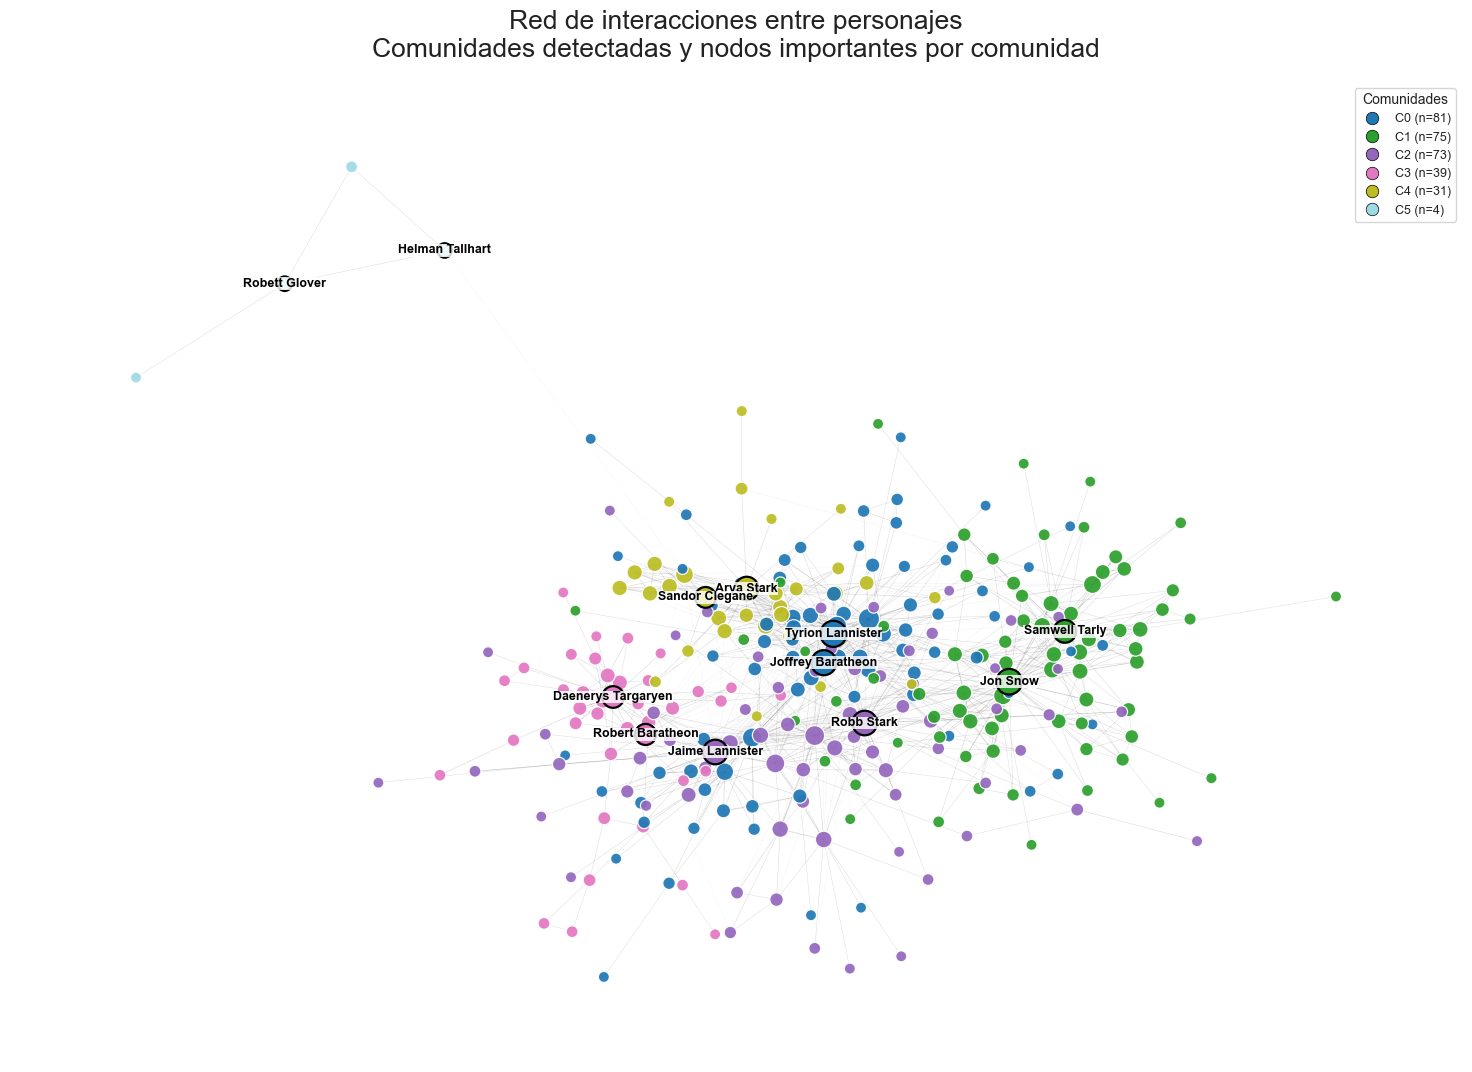

In [174]:
# ============================================================
# 11. Visualización mejorada de la red + comunidades compactas
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np
from networkx.algorithms.community import greedy_modularity_communities

# ------------------------------------------------------------
# 1. Componente principal
# ------------------------------------------------------------
largest_cc = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()

# ------------------------------------------------------------
# 2. Detectar comunidades
# ------------------------------------------------------------
communities = list(greedy_modularity_communities(G_main))
communities = sorted(communities, key=len, reverse=True)

community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

print(f"Número de comunidades detectadas: {len(communities)}")
print("Tamaños:", [len(c) for c in communities])

# ------------------------------------------------------------
# 3. Construir meta-grafo entre comunidades
#    Cada nodo del meta-grafo es una comunidad
#    El peso entre comunidades es el número de aristas entre ellas
# ------------------------------------------------------------
meta_G = nx.Graph()
meta_G.add_nodes_from(range(len(communities)))

for u, v in G_main.edges():
    cu = community_map[u]
    cv = community_map[v]
    if cu != cv:
        if meta_G.has_edge(cu, cv):
            meta_G[cu][cv]["weight"] += 1
        else:
            meta_G.add_edge(cu, cv, weight=1)

# Layout para comunidades
meta_pos = nx.spring_layout(meta_G, seed=42, k=2.5)

# ------------------------------------------------------------
# 4. Layout jerárquico:
#    - primero ubicamos cada comunidad
#    - luego ubicamos nodos dentro de su propia comunidad
# ------------------------------------------------------------
pos = {}

# Escala global entre comunidades
community_scale = 4.0

# Escala interna dentro de cada comunidad
# Comunidades grandes reciben un poco más de espacio interno
for i, comm in enumerate(communities):
    subG = G_main.subgraph(comm).copy()

    # layout interno de la comunidad
    if len(subG) == 1:
        local_pos = {list(subG.nodes())[0]: np.array([0.0, 0.0])}
    else:
        local_k = 1.2 / np.sqrt(len(subG))
        local_pos = nx.spring_layout(subG, seed=42, k=local_k)

    center = meta_pos[i] * community_scale
    internal_scale = 1.2 + 0.03 * len(subG)

    for n in subG.nodes():
        pos[n] = center + internal_scale * local_pos[n]

# ------------------------------------------------------------
# 5. Métricas para visualización
# ------------------------------------------------------------
degree_dict_main = dict(G_main.degree())
weighted_degree_dict = dict(G_main.degree(weight="weight"))

# Tamaño de nodo: más bonito y estable
node_sizes = [
    40 + 18 * np.sqrt(degree_dict_main[n]) + 3 * np.sqrt(weighted_degree_dict[n])
    for n in G_main.nodes()
]

# Color de nodo según comunidad
node_community_ids = np.array([community_map[n] for n in G_main.nodes()])
cmap = cm.get_cmap("tab20", len(communities))

# ------------------------------------------------------------
# 6. Separar aristas intra/inter comunidad
# ------------------------------------------------------------
intra_edges = []
inter_edges = []

for u, v in G_main.edges():
    if community_map[u] == community_map[v]:
        intra_edges.append((u, v))
    else:
        inter_edges.append((u, v))

def edge_width(u, v):
    w = G_main[u][v].get("weight", 1)
    return 0.2 + 0.08 * np.sqrt(w)

intra_widths = [edge_width(u, v) for u, v in intra_edges]
inter_widths = [edge_width(u, v) for u, v in inter_edges]

# ------------------------------------------------------------
# 7. Elegir nodos importantes por comunidad
#    Aquí usamos grado ponderado dentro del grafo global
#    y tomamos el top 2 de cada comunidad
# ------------------------------------------------------------
labels = {}
top_nodes_by_community = []

for i, comm in enumerate(communities):
    comm_nodes_sorted = sorted(
        list(comm),
        key=lambda n: weighted_degree_dict[n],
        reverse=True
    )
    top_comm = comm_nodes_sorted[:2]   # cambia a [:1] si quieres menos labels
    top_nodes_by_community.extend(top_comm)
    for n in top_comm:
        labels[n] = n.replace("-", " ")

# ------------------------------------------------------------
# 8. Dibujar
# ------------------------------------------------------------
plt.figure(figsize=(15, 11))

# Aristas entre comunidades: muy suaves
nx.draw_networkx_edges(
    G_main,
    pos,
    edgelist=inter_edges,
    width=inter_widths,
    alpha=0.04
)

# Aristas dentro de comunidades: más visibles
nx.draw_networkx_edges(
    G_main,
    pos,
    edgelist=intra_edges,
    width=intra_widths,
    alpha=0.14
)

# Dibujar todos los nodos
nodes = nx.draw_networkx_nodes(
    G_main,
    pos,
    node_size=node_sizes,
    node_color=node_community_ids,
    cmap=cmap,
    alpha=0.92,
    linewidths=0.9,
    edgecolors="white"
)

# Destacar nodos importantes por comunidad
nx.draw_networkx_nodes(
    G_main,
    pos,
    nodelist=top_nodes_by_community,
    node_size=[1.35 * (40 + 18 * np.sqrt(degree_dict_main[n]) + 3 * np.sqrt(weighted_degree_dict[n]))
               for n in top_nodes_by_community],
    node_color=[community_map[n] for n in top_nodes_by_community],
    cmap=cmap,
    alpha=1.0,
    linewidths=1.6,
    edgecolors="black"
)

# Labels solo para nodos importantes por comunidad
text_items = nx.draw_networkx_labels(
    G_main,
    pos,
    labels=labels,
    font_size=9,
    font_weight="bold"
)

for _, text in text_items.items():
    text.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.82, pad=0.22))

# ------------------------------------------------------------
# 9. Leyenda simple por comunidad (tamaño)
# ------------------------------------------------------------
community_sizes = [len(c) for c in communities]
legend_labels = [f"C{i} (n={community_sizes[i]})" for i in range(len(communities))]

# Creamos handles manuales
handles = []
for i in range(len(communities)):
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=cmap(i),
            markeredgecolor='black',
            markeredgewidth=0.5,
            markersize=9,
            label=legend_labels[i]
        )
    )

plt.legend(
    handles=handles,
    title="Comunidades",
    loc="upper right",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

plt.title(
    "Red de interacciones entre personajes\nComunidades detectadas y nodos importantes por comunidad",
    fontsize=19,
    pad=18
)

plt.axis("off")
plt.tight_layout()
plt.show()

## 12) Conclusión

En este notebook hicimos el flujo mínimo que usaremos muchas veces en el curso:

**datos crudos → edgelist → grafo → matriz → grado → QA básico**

### Preguntas para discutir
1. ¿Qué representa exactamente una arista en este dataset?
2. ¿Qué cambia si ignoramos el peso?
3. ¿Qué cambiaría si esta red fuera dirigida?
4. ¿Qué chequeos adicionales harías antes de analizar centralidad o comunidades?